# **Atividade Prática**
<font size=3>

- **Tema:** Agentes inteligentes.
- **Prazo de entrega:** 01 de Setembro.

**Envie** a atividade pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeUFqt61PGKmPpD6AEIOIO6XzVi71ZmuWxeWH0JfMFWeaSMnQ/viewform?usp=header).

---

### **Enunciado:**
<font size=3>
    
Crie um exemplo de **agente reflexo simples** e faça:
 1. A descrição do **PEAS** (_Performance, Ambiente, Atuadores e Sensores_);
 2. A implementação do **programa do agente** em Python de acordo com o pseudocódigo abaixo.

<font size=2>
    
>```pseudocode
>function SIMPLE-REFLEX-AGENT(percept) returns an action
>        persistent: rules, a set of condition-action rules
>
>    state ← INTERPRET-INPUT(percept)
>    rule ← RULE-MATCH(state, rules)
>    action ← rule.ACTION
>
>    return action
>```

<font size=3><center>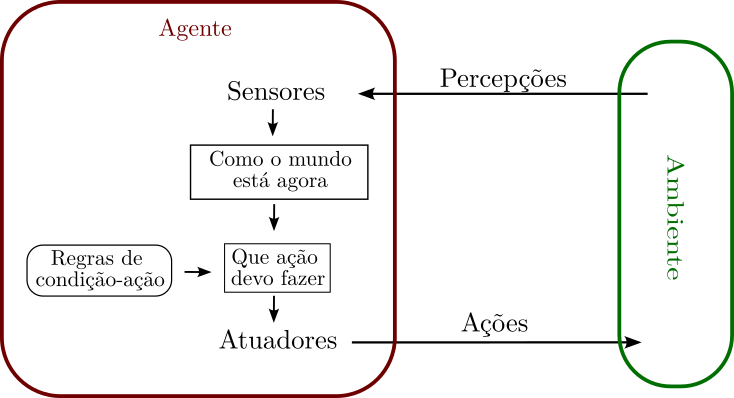</center>

---

### **Resposta:**
<font size=3>

- **Exemplo de agente:** Ducha inteligente para pet
- **PEAS:**

| Categoria       | Descrição                                                                 |
|-----------------|---------------------------------------------------------------------------|
| **Performance** | Deixar o pet limpo, temperatuda da agua adequada, economia de agua, segurança, feedback do tutor|
| **Ambiente**    | Quintal|
| **Atuadores**   | Ligar/desligar a ducha, controle de temperatura da agua, pequena grade automática para manter o pet no local, ducha para shampoo e para enxaguar, sistema de secagem|
| **Sensores**    | Sensor de presença, sensor climatico, sensor de sujeira, sensor de temperatura da agua, sensor de movimento (para detectar o pet)|

In [ ]:
class SimpleReflexAgent:

    def __call__(self, percept):

        state = self.interpret_input(percept)
        action = self.rule_match(state)

        return action

    def interpret_input(self, percept):
        raise NotImplementedError("Este método deve ser implementado na subclasse.")

    def rule_match(self, state):
        raise NotImplementedError("Este método deve ser implementado na subclasse.")


In [ ]:
class duchaPet(SimpleReflexAgent):
    def interpret_input(self, percept):
        pet, sujeira, ducha, clima, grade, banho = percept

        #pet: presente ou ausente
        #sujeira: sim ou não
        #ducha: ligada ou desligada
        #clima: sol ou chuva
        #grade: aberta ou fechada
        #banho realizado: sim ou não


        return {
            "pet": pet,
            "sujeira": sujeira,
            "ducha": ducha,
            "clima": clima,
            "grade": grade,
            "banho": banho
        }

    def rule_match(self, state):
        if (
            state["clima"] == "sol"
            and state["pet"] == "presente"
            and state["sujeira"] == "sim"
            and state["grade"] == "fechada"
            and state["banho"] == "nao"
        ):
            return "Ligar ducha e passar shampoo"

        elif (
            state["clima"] == "sol"
            and state["pet"] == "presente"
            and state["sujeira"] == "nao"
            and state["grade"] == "fechada"
            and state["banho"] == "sim"
        ):
            return "Enxaguar e secar o pet"

        elif (
            state["clima"] == "chuva"
            and state["pet"] == "presente"
            and state["sujeira"] == "sim"
            and state["grade"] == "fechada"
            and state["banho"] == "nao"
        ):
            return "Adiar o banho"

        elif (
            state["clima"] == "sol"
            and state["pet"] == "ausente"
            and state["grade"] == "aberta"
        ):
            return "Tutor, por favor trazer o pet"

        elif (
            state["clima"] == "chuva"
            and state["pet"] == "ausente"
            and state["grade"] == "aberta"
        ):
            return "Tutor, adiar o banho"

        else:
            return "Aguardar"


In [ ]:
ducha = duchaPet()


print("Exemplos de situações: ")
print("\n")
print(ducha(("presente", "sim", "desligada", "sol", "fechada", "nao")))
print("--------------")
print(ducha(("presente", "nao", "ligada", "sol", "fechada", "sim")))
print("--------------")
print(ducha(("presente", "sim", "ligada", "chuva", "fechada", "nao")))
print("--------------")
print(ducha(("ausente", "nao", "desligada", "sol", "aberta", "nao")))
print("--------------")
print(ducha(("ausente", "nao", "desligada", "chuva", "aberta", "nao")))



Exemplos de situações: 


Ligar ducha e passar shampoo
--------------
Enxaguar e secar o pet
--------------
Adiar o banho
--------------
Tutor, por favor trazer o pet
--------------
Tutor, adiar o banho
